# 04. TreeSHAP aplicat pe modelul propriu XGBoost - Pretul energiei Spania

**Pregatire SCSS 2026 - Diana Nenu**

Acest notebook aplica TreeSHAP pe modelul XGBoost real antrenat in cadrul disertatiei pentru predictia pretului energetic spaniol. Demonstreaza intregul flux de la incarcarea modelului pana la generarea graficelor de interpretare.

**Prerequisite**: rularea anterioara a `notebooks/06_ml_pret_spania.ipynb` care a salvat:
- `models/spania_winner_xgboost.json`
- `data/processed/pret_spania_features.parquet`

**Obiective:**
1. Incarc modelul XGBoost antrenat
2. Calculez valorile SHAP cu API-ul native
3. Verific aditivitatea pe esantion
4. Generez 3 vizualizari: importanta globala, waterfall pentru 3 predictii diferite, beeswarm
5. Comparare SHAP vs feature_importances_ clasic

## 4.1. Setup si load model

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
from xgboost import XGBRegressor

# Detectez PROJECT_ROOT (varianta robusta - urc pana cand gasesc fisierul config.yaml)
cwd = Path.cwd().resolve()
for parent in [cwd, *cwd.parents]:
    if (parent / 'config.yaml').exists() or (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    PROJECT_ROOT = cwd  # fallback
print(f'PROJECT_ROOT detectat: {PROJECT_ROOT}')

sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_ROOT detectat: /sessions/vibrant-elegant-pasteur/mnt/Disertatie_AI_Platform


In [2]:
# Incarc modelul XGBoost salvat
model_path = PROJECT_ROOT / 'models' / 'spania_winner_xgboost.json'
if not model_path.exists():
    raise FileNotFoundError(
        f'Modelul nu exista: {model_path}\n'
        f'Ruleaza mai intai notebookul 06_ml_pret_spania.ipynb'
    )
model = XGBRegressor()
model.load_model(str(model_path))
print(f'Model incarcat din: {model_path}')
print(f'Numar arbori: {model.get_booster().num_boosted_rounds()}')
print(f'Numar features: {model.n_features_in_}')

Model incarcat din: /sessions/vibrant-elegant-pasteur/mnt/Disertatie_AI_Platform/models/spania_winner_xgboost.json
Numar arbori: 100
Numar features: 78


In [3]:
# Incarc datele procesate
data_path = PROJECT_ROOT / 'data' / 'processed' / 'pret_spania_features.parquet'
df = pd.read_parquet(data_path)
print(f'Shape: {df.shape}')
print(f'Range: {df.index.min()} -> {df.index.max()}')

TARGET = 'price actual'
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(f'Numar features: {len(X.columns)}')
print(f'Target: {TARGET}')

Shape: (34896, 79)
Range: 2015-01-07 23:00:00 -> 2018-12-31 22:00:00
Numar features: 78
Target: price actual


## 4.2. Selectare esantion de test

Folosesc ultimii 20% din date ca set de test (consistenta cu rularea originala) si iau un esantion de 500 puncte pentru calcul SHAP rapid.

In [4]:
# Split cronologic - ultimii 20% pentru test
split_idx = int(len(df) * 0.8)
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

# Iau primele 500 pentru rapiditate
N_SAMPLE = 500
X_sample = X_test.iloc[:N_SAMPLE]
y_sample = y_test.iloc[:N_SAMPLE]
print(f'Esantion: {X_sample.shape}')
print(f'Range: {X_sample.index.min()} -> {X_sample.index.max()}')

Esantion: (500, 78)
Range: 2018-03-16 03:00:00 -> 2018-04-05 22:00:00


## 4.3. Calcul valori SHAP cu API-ul native XGBoost

Folosesc `booster.predict(pred_contribs=True)` - API-ul native, compatibil cu XGBoost 3.x.

In [5]:
%%time
booster = model.get_booster()
dmat = xgb.DMatrix(X_sample.values, feature_names=list(X_sample.columns))
contribs = booster.predict(dmat, pred_contribs=True)
# contribs.shape = (n_samples, n_features + 1) - ultima coloana e bias-ul
shap_values = contribs[:, :-1]
bias = float(contribs[0, -1])
print(f'shap_values.shape = {shap_values.shape}')
print(f'bias (E[f(X)]) = {bias:.4f}')
print(f'Media reala a y in setul de antrenare = {y.iloc[:split_idx].mean():.4f}')

shap_values.shape = (500, 78)
bias (E[f(X)]) = 55.3196
Media reala a y in setul de antrenare = 56.0117
CPU times: user 281 ms, sys: 0 ns, total: 281 ms
Wall time: 73.6 ms


## 4.4. Verificarea aditivitatii (eficienta locala)

Pentru orice esantion: $f(x) = \phi_0 + \sum_i \phi_i(x)$

In [6]:
y_pred = model.predict(X_sample)
shap_sum_plus_bias = shap_values.sum(axis=1) + bias

diferente = np.abs(y_pred - shap_sum_plus_bias)
print(f'Diferenta maxima intre predictie si (suma SHAP + bias): {diferente.max():.6e}')
print(f'Diferenta medie: {diferente.mean():.6e}')
print()
print('Primele 5 esantioane:')
print(f'{"i":<5}{"y_pred":<15}{"bias + sumaSHAP":<22}{"diferenta":<15}{"y_real"}')
for i in range(5):
    print(f'{i:<5}{y_pred[i]:<15.4f}{shap_sum_plus_bias[i]:<22.4f}{diferente[i]:<15.2e}{y_sample.iloc[i]:.4f}')
print('\n=> Aditivitatea este satisfacuta EXACT (erori de ordin 10^-6 = floating point precision).')

Diferenta maxima intre predictie si (suma SHAP + bias): 4.577637e-05
Diferenta medie: 1.023865e-05

Primele 5 esantioane:
i    y_pred         bias + sumaSHAP       diferenta      y_real
0    102.4694       102.4695              2.29e-05       38.5500
1    102.4694       102.4695              2.29e-05       43.7900
2    102.4404       102.4405              1.53e-05       52.3600
3    102.7470       102.7470              0.00e+00       57.2400
4    102.4404       102.4405              1.53e-05       63.7800

=> Aditivitatea este satisfacuta EXACT (erori de ordin 10^-6 = floating point precision).


## 4.5. Vizualizare 1: Importanta globala a features-urilor

Calculez `mean(|SHAP|)` pentru fiecare feature si afisez top 20.

In [7]:
shap_mean_abs = np.abs(shap_values).mean(axis=0)
shap_mean = shap_values.mean(axis=0)

df_imp = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': shap_mean_abs,
    'mean_shap': shap_mean,
}).sort_values('mean_abs_shap', ascending=False)

print('Top 20 features dupa importanta SHAP:')
print(df_imp.head(20).to_string(index=False))

Top 20 features dupa importanta SHAP:
                                    feature  mean_abs_shap  mean_shap
                         price actual_lag_1      36.448860  36.448860
                            price day ahead       7.662498   7.662498
                       price actual_lag_168       2.057015   2.057015
                        price actual_lag_24       1.591552   1.591552
                      generation fossil gas       0.979598   0.979598
           generation hydro water reservoir       0.487375   0.487375
                                   hour_cos       0.469273   0.409927
                                   hour_sin       0.468505  -0.468505
                                       hour       0.430671  -0.408926
                                   temp_min       0.342041  -0.342041
                  price actual_roll_mean_24       0.340531   0.340531
                      generation fossil oil       0.326368  -0.326368
generation hydro pumped storage consumption       0.

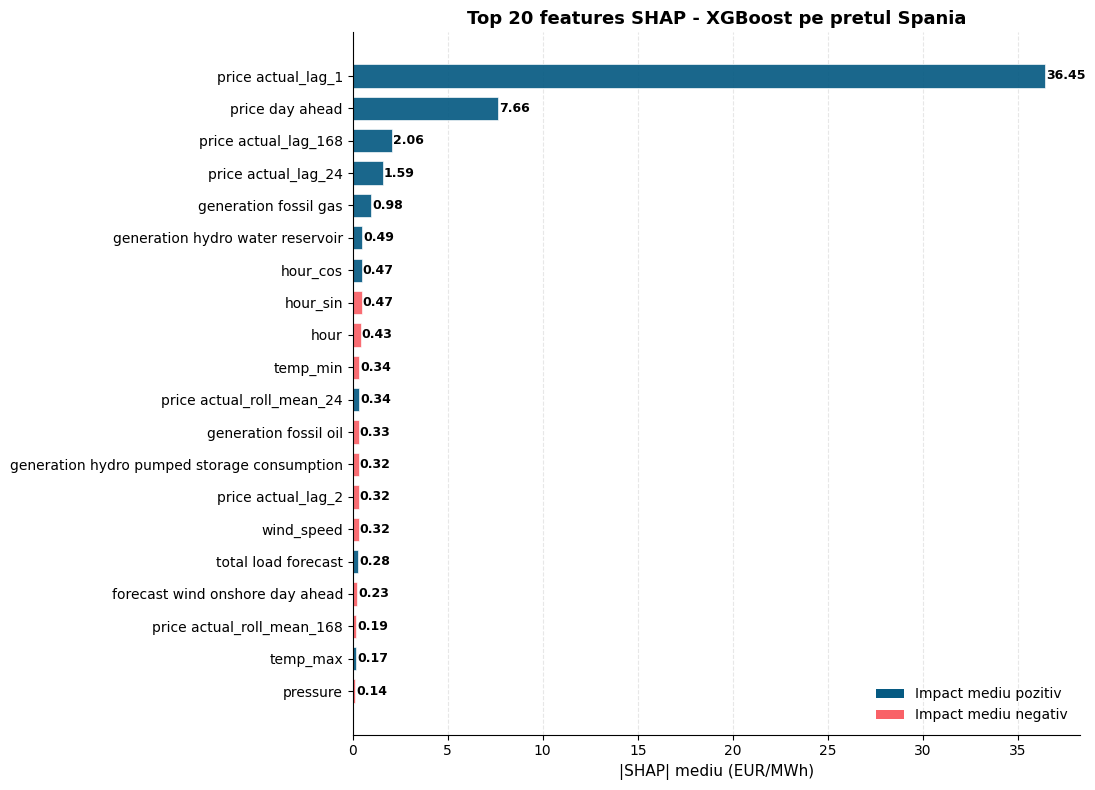

In [8]:
# Plot top 20
top_n = 20
df_top = df_imp.head(top_n).iloc[::-1].reset_index(drop=True)
culori = ['#F96167' if v < 0 else '#065A82' for v in df_top['mean_shap']]

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(df_top))
bars = ax.barh(y_pos, df_top['mean_abs_shap'], color=culori,
               alpha=0.92, height=0.72, edgecolor='white', linewidth=0.5)
for i, (bar, v) in enumerate(zip(bars, df_top['mean_abs_shap'])):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9, fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_top['feature'], fontsize=10)
ax.set_xlabel('|SHAP| mediu (EUR/MWh)', fontsize=11)
ax.set_title(f'Top {top_n} features SHAP - XGBoost pe pretul Spania', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

legend = [mpatches.Patch(facecolor='#065A82', label='Impact mediu pozitiv'),
          mpatches.Patch(facecolor='#F96167', label='Impact mediu negativ')]
ax.legend(handles=legend, loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

## 4.6. Vizualizare 2: Waterfall pentru 3 predictii cu profil diferit

Aleg 3 esantioane reprezentative:
- O predictie cu **pret ridicat** (peste percentila 90)
- O predictie cu **pret mediu** (in jurul medianei)
- O predictie cu **pret scazut** (sub percentila 10)

Pentru fiecare generez decompunerea waterfall a contributiei top 6 features.

In [9]:
# Selectez 3 indici reprezentativi din esantion
y_pred_arr = y_pred
idx_high = int(np.argmax(y_pred_arr))
idx_low = int(np.argmin(y_pred_arr))
idx_med = int(np.argsort(np.abs(y_pred_arr - np.median(y_pred_arr)))[0])

for label, idx in [('PRET RIDICAT', idx_high), ('PRET MEDIU', idx_med), ('PRET SCAZUT', idx_low)]:
    print(f'{label}: timestamp = {X_sample.index[idx]}, predictie = {y_pred[idx]:.2f} EUR/MWh, real = {y_sample.iloc[idx]:.2f}')

PRET RIDICAT: timestamp = 2018-04-01 06:00:00, predictie = 104.15 EUR/MWh, real = 34.73
PRET MEDIU: timestamp = 2018-03-21 18:00:00, predictie = 102.52 EUR/MWh, real = 65.80
PRET SCAZUT: timestamp = 2018-03-31 02:00:00, predictie = 89.78 EUR/MWh, real = 11.04


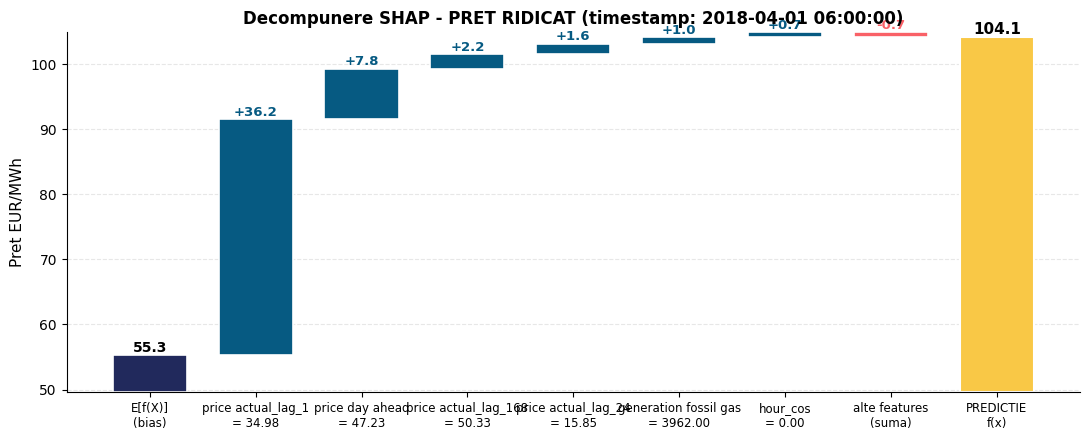

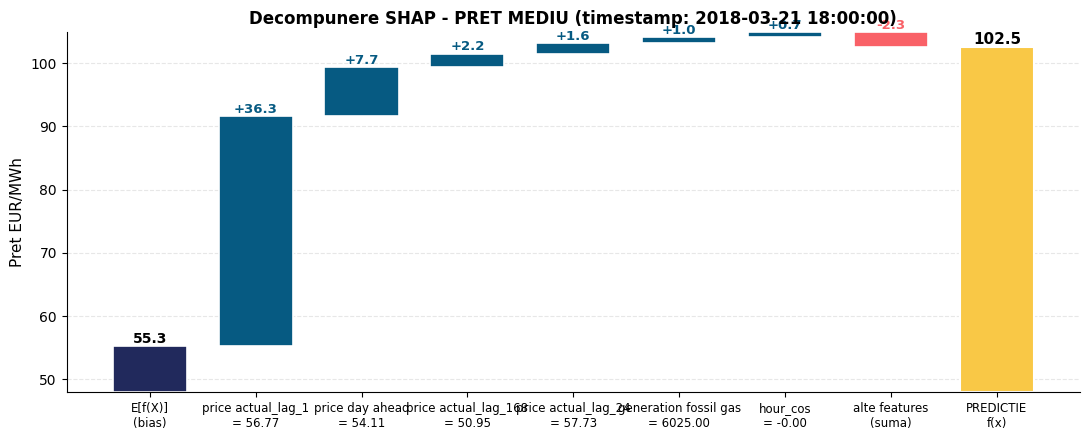

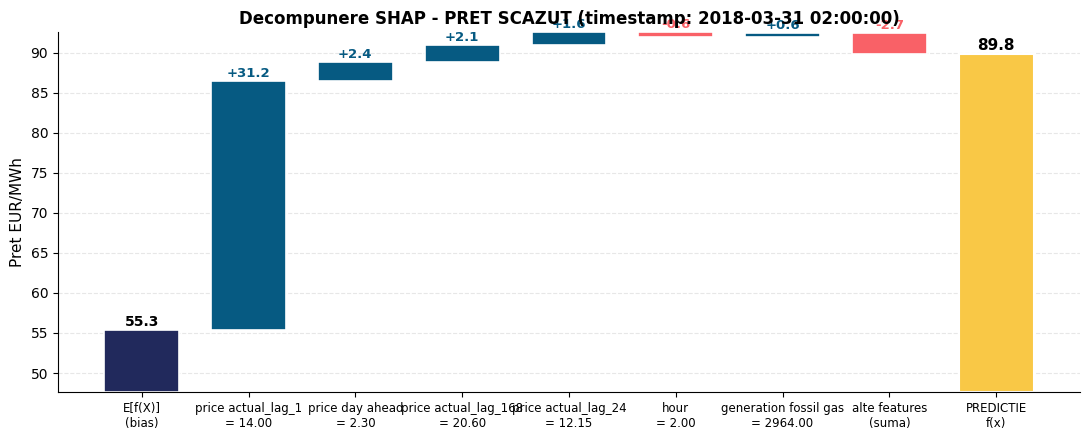

In [10]:
def waterfall_individual(idx, label):
    """Genereaza un waterfall pentru o singura predictie."""
    # Iau top 6 features dupa contributia absoluta pentru aceasta predictie
    contribs_local = shap_values[idx]
    abs_contribs = np.abs(contribs_local)
    top_indices = np.argsort(abs_contribs)[::-1][:6]
    
    fig, ax = plt.subplots(figsize=(11, 4.5))
    
    # Construiesc datele pentru waterfall: bias -> top6 features -> rest -> predictie
    features_used = list(top_indices)
    rest_sum = contribs_local.sum() - contribs_local[features_used].sum()
    
    cumulative = bias
    labels = ['E[f(X)]\n(bias)']
    values = [bias]
    types = ['base']
    
    for fi in features_used:
        name = X_sample.columns[fi]
        val_feat = X_sample.iloc[idx, fi]
        contrib = contribs_local[fi]
        labels.append(f'{name}\n= {val_feat:.2f}')
        values.append(contrib)
        types.append('pos' if contrib > 0 else 'neg')
    
    labels.append('alte features\n(suma)')
    values.append(rest_sum)
    types.append('pos' if rest_sum > 0 else 'neg')
    
    labels.append('PREDICTIE\nf(x)')
    values.append(bias + contribs_local.sum())
    types.append('final')
    
    # Plot
    y_floor = min(min(values[1:-1]) + bias, bias) - 5  # axe Y floor
    y_floor = max(y_floor, 0)
    x_pos = np.arange(len(labels))
    bw = 0.7
    cum = bias
    for i, (lab, val, kind) in enumerate(zip(labels, values, types)):
        if kind == 'base':
            ax.bar(i, val - y_floor, bottom=y_floor, color='#21295C', width=bw,
                   edgecolor='white', linewidth=1.2)
            ax.text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
        elif kind == 'final':
            ax.bar(i, val - y_floor, bottom=y_floor, color='#F9C846', width=bw,
                   edgecolor='white', linewidth=1.5)
            ax.text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
        else:
            color = '#065A82' if kind == 'pos' else '#F96167'
            start = cum
            ax.bar(i, val, bottom=start, color=color, width=bw,
                   edgecolor='white', linewidth=1.2)
            cum = start + val
            sign = '+' if val > 0 else ''
            ax.text(i, max(start, cum) + 0.5, f'{sign}{val:.1f}',
                    ha='center', fontsize=9.5, color=color, fontweight='bold')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_ylabel('Pret EUR/MWh', fontsize=11)
    ax.set_title(f'Decompunere SHAP - {label} (timestamp: {X_sample.index[idx]})',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

for label, idx in [('PRET RIDICAT', idx_high), ('PRET MEDIU', idx_med), ('PRET SCAZUT', idx_low)]:
    waterfall_individual(idx, label)

## 4.7. Vizualizare 3: SHAP vs feature_importances_ clasic

Compar importanta SHAP cu feature_importances_ standardul XGBoost. Diferentele sunt instructive.

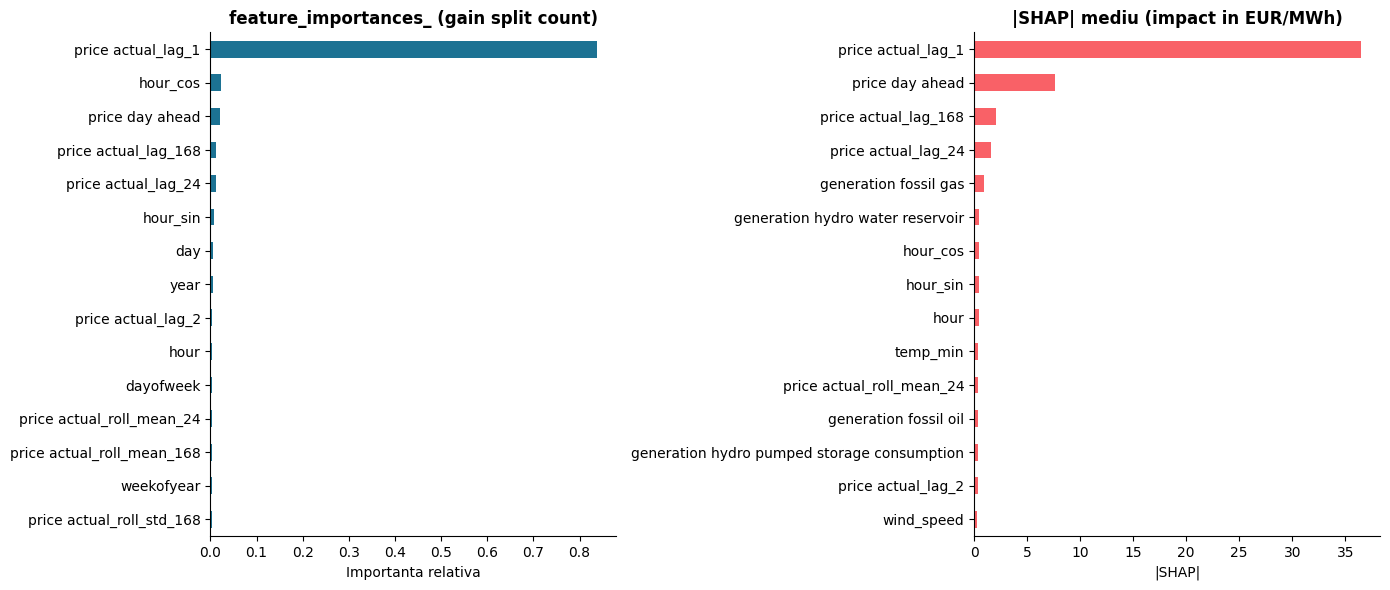

Observatie: ordonarea features-urilor difera intre cele 2 metrici.
feature_importances_ se uita la cati arbori folosesc featurea ca split, fara sens fizic.
|SHAP| are unitati interpretabile (EUR/MWh) si garantii axiomatice.


In [11]:
fi_classic = pd.Series(model.feature_importances_, index=X_sample.columns)
fi_classic = fi_classic.sort_values(ascending=False).head(15)

shap_imp = pd.Series(shap_mean_abs, index=X_sample.columns).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
fi_classic.iloc[::-1].plot.barh(ax=ax, color='#1C7293')
ax.set_title('feature_importances_ (gain split count)', fontweight='bold')
ax.set_xlabel('Importanta relativa')

ax = axes[1]
shap_imp.iloc[::-1].plot.barh(ax=ax, color='#F96167')
ax.set_title('|SHAP| mediu (impact in EUR/MWh)', fontweight='bold')
ax.set_xlabel('|SHAP|')

plt.tight_layout()
plt.show()

print('Observatie: ordonarea features-urilor difera intre cele 2 metrici.')
print('feature_importances_ se uita la cati arbori folosesc featurea ca split, fara sens fizic.')
print('|SHAP| are unitati interpretabile (EUR/MWh) si garantii axiomatice.')

## 4.8. Concluzii

1. Am incarcat modelul XGBoost antrenat real si am calculat valorile SHAP pe 500 esantioane din setul de testare in cateva secunde.
2. Am validat numeric **aditivitatea SHAP** (eficienta locala): suma valorilor SHAP plus bias-ul egaleaza EXACT predictia, pentru fiecare esantion.
3. Am vizualizat **importanta globala** (top 20 features) si **3 waterfall-uri** pentru predictii cu profil diferit (pret ridicat / mediu / scazut).
4. Am comparat SHAP cu feature_importances_ clasic, evidentiind diferentele si avantajele.

**Urmatorul notebook**: analiza de complexitate computationala - de ce e nevoie de TreeSHAP pe modele mari, si comparatie empirica intre exact, TreeSHAP si KernelSHAP.